### Libraries

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from keras.datasets import imdb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

### IMDB Dataset

In [2]:
vocab_size = 10000
max_len = 256

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Train samples:", len(x_train))
print("Test samples:", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train samples: 25000
Test samples: 25000


### Pad Sequences

In [3]:
from keras.preprocessing.sequence import pad_sequences

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

x_train = torch.tensor(x_train)
y_train = torch.tensor(y_train).float()

x_test = torch.tensor(x_test)
y_test = torch.tensor(y_test).float()

### DataLoader

In [4]:
from torch.utils.data import DataLoader, TensorDataset

batch_size = 64

train_data = TensorDataset(x_train, y_train)
test_data = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size)

### Model Architecture

In [5]:
class SentimentModel(nn.Module):

    def __init__(self, rnn_type):

        super().__init__()
        self.embed = nn.Embedding(vocab_size, 100)

        if rnn_type == "rnn":
            self.rnn = nn.RNN(100,128,batch_first=True)

        elif rnn_type == "lstm":
            self.rnn = nn.LSTM(100,128,batch_first=True)

        elif rnn_type == "gru":
            self.rnn = nn.GRU(100,128,batch_first=True)

        self.fc = nn.Linear(128,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):

        x = self.embed(x)
        out,_ = self.rnn(x)
        out = out[:,-1,:]
        out = self.fc(out)
        out = self.sigmoid(out)

        return out

In [6]:
def train_model(model):

    loss_fn = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(5):
        total = 0

        for x,y in train_loader:

            pred = model(x).squeeze()
            loss = loss_fn(pred,y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total += loss.item()

        print("Epoch",epoch+1,"Loss:", total/len(train_loader))

### Training

In [8]:
rnn_model = SentimentModel("rnn")
lstm_model = SentimentModel("lstm")
gru_model = SentimentModel("gru")

print("Training RNN")
train_model(rnn_model)

print("Training LSTM")
train_model(lstm_model)

print("Training GRU")
train_model(gru_model)

Training RNN
Epoch 1 Loss: 0.6439024202354119
Epoch 2 Loss: 0.6158781036391587
Epoch 3 Loss: 0.634836409479151
Epoch 4 Loss: 0.5976903645888619
Epoch 5 Loss: 0.5195516766337178
Training LSTM
Epoch 1 Loss: 0.5764577605230424
Epoch 2 Loss: 0.46026374517804214
Epoch 3 Loss: 0.4884426362069367
Epoch 4 Loss: 0.37419679787610194
Epoch 5 Loss: 0.28542979579904804
Training GRU
Epoch 1 Loss: 0.5828086155302384
Epoch 2 Loss: 0.38803213769974915
Epoch 3 Loss: 0.2730369191531025
Epoch 4 Loss: 0.20843836627043116
Epoch 5 Loss: 0.15656393423409717


### Evaluation Function

In [9]:
def evaluate(model):

    preds = []
    labels = []

    with torch.no_grad():

        for x,y in test_loader:

            out = model(x).squeeze()
            p = (out > 0.5).int()

            preds.extend(p.tolist())
            labels.extend(y.tolist())

    acc = accuracy_score(labels,preds)
    prec = precision_score(labels,preds)
    rec = recall_score(labels,preds)
    f1 = f1_score(labels,preds)

    return acc,prec,rec,f1,confusion_matrix(labels,preds)

In [10]:
rnn_metrics = evaluate(rnn_model)
lstm_metrics = evaluate(lstm_model)
gru_metrics = evaluate(gru_model)

print("RNN:", rnn_metrics[:4])
print("LSTM:", lstm_metrics[:4])
print("GRU:", gru_metrics[:4])

RNN: (0.71628, 0.7411901150860916, 0.66464, 0.7008309080939727)
LSTM: (0.8552, 0.8399173174092788, 0.87768, 0.8583835380643142)
GRU: (0.88588, 0.8986034212048591, 0.86992, 0.8840291045079468)


### Comparison

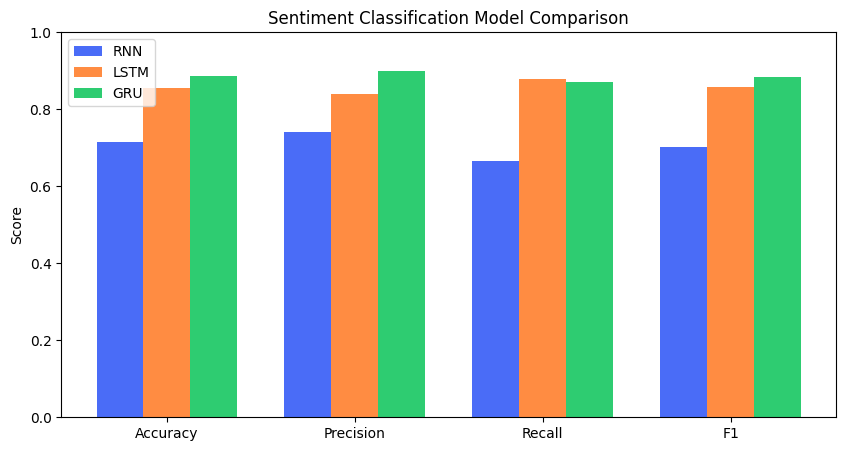

In [11]:
metrics = ["Accuracy","Precision","Recall","F1"]

rnn = rnn_metrics[:4]
lstm = lstm_metrics[:4]
gru = gru_metrics[:4]

x = np.arange(len(metrics))
w = 0.25

plt.figure(figsize=(10,5))

plt.bar(x-w, rnn, width=w, label="RNN", color="#4A6CF7")
plt.bar(x, lstm, width=w, label="LSTM", color="#FF8C42")
plt.bar(x+w, gru, width=w, label="GRU", color="#2ECC71")

plt.xticks(x, metrics)
plt.ylim(0,1)

plt.title("Sentiment Classification Model Comparison")
plt.ylabel("Score")

plt.legend()
plt.show()

In [12]:
print("RNN Confusion Matrix\n", rnn_metrics[4])
print("\nLSTM Confusion Matrix\n", lstm_metrics[4])
print("\nGRU Confusion Matrix\n", gru_metrics[4])

RNN Confusion Matrix
 [[9599 2901]
 [4192 8308]]

LSTM Confusion Matrix
 [[10409  2091]
 [ 1529 10971]]

GRU Confusion Matrix
 [[11273  1227]
 [ 1626 10874]]
